<a href="https://colab.research.google.com/github/JustineDataEng/Alcohol-Consumption-Analysis-KNN/blob/main/ML_KNN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('/content/russian_alcohol_consumption.csv')
df.head()


,year,region,wine,beer,vodka,champagne,brandy
0,1998,Republic of Adygea,1.9,8.8,3.4,0.3,0.1
1,1998,Altai Krai,3.3,19.2,11.3,1.1,0.1
2,1998,Amur Oblast,2.1,21.2,17.3,0.7,0.4
3,1998,Arkhangelsk Oblast,4.3,10.6,11.7,0.4,0.3
4,1998,Astrakhan Oblast,2.9,18.0,9.5,0.8,0.2


In [ ]:
df.isnull().sum()

,0
year,0
region,0
wine,63
beer,58
vodka,61
champagne,63
brandy,66


In [ ]:
null_columns = ['wine', 'beer', 'vodka', 'champagne', 'brandy']

In [ ]:
null_colums = ['wine', 'beer', 'vodka', 'champagne', 'brandy']
for col in null_columns:
    mean_val = df[col].mean()
    df[col].fillna(mean_val, inplace=True)

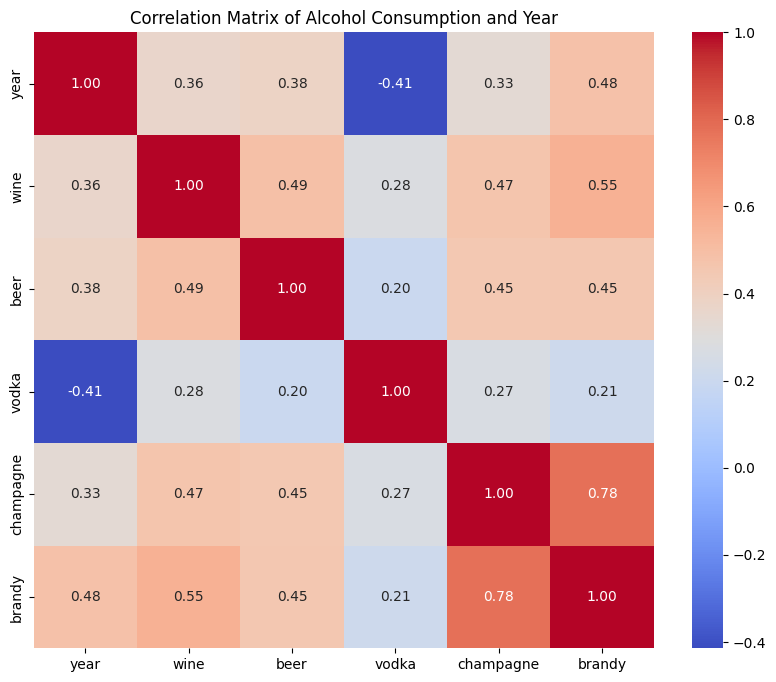

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

alcohol_cols = ['year', 'wine', 'beer', 'vodka', 'champagne', 'brandy']
correlation_df = df[alcohol_cols]

correlation_matrix = correlation_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Alcohol Consumption and Year')
plt.show()

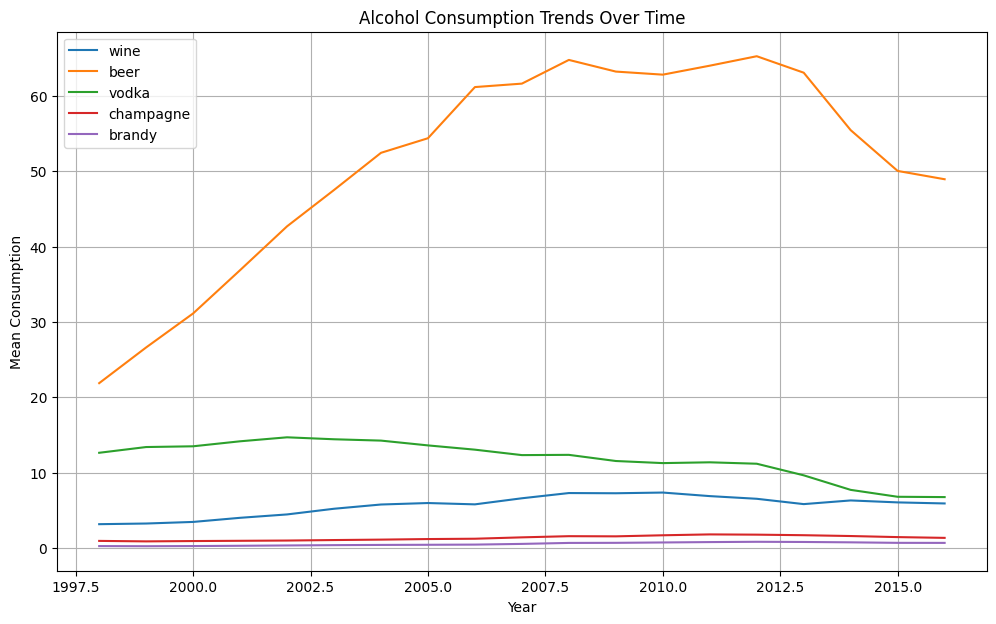

In [ ]:
df_trends = df.groupby('year')[['wine', 'beer', 'vodka', 'champagne', 'brandy']].mean()

plt.figure(figsize=(12, 7))
for column in df_trends.columns:
    plt.plot(df_trends.index, df_trends[column], label=column)

plt.title('Alcohol Consumption Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Mean Consumption')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df['total_alcohol_consumption'] = df['wine'] + df['beer'] + df['vodka'] + df['champagne'] + df['brandy']
df['total_alcohol_consumption_level'] = pd.qcut(df['total_alcohol_consumption'], q=3, labels=['low', 'medium', 'high'])

y_reg = df['total_alcohol_consumption']
y_class = df['total_alcohol_consumption_level']
df.head()

,year,region,wine,beer,vodka,champagne,brandy,total_alcohol_consumption,total_alcohol_consumption_level
0,1998,Republic of Adygea,1.9,8.8,3.4,0.3,0.1,14.5,low
1,1998,Altai Krai,3.3,19.2,11.3,1.1,0.1,35.0,low
2,1998,Amur Oblast,2.1,21.2,17.3,0.7,0.4,41.7,low
3,1998,Arkhangelsk Oblast,4.3,10.6,11.7,0.4,0.3,27.3,low
4,1998,Astrakhan Oblast,2.9,18.0,9.5,0.8,0.2,31.4,low


In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
region_encoded = encoder.fit_transform(df[['region']])
region_encoded_df = pd.DataFrame(region_encoded, columns=encoder.get_feature_names_out(['region']))
region_encoded_df.head()

,region_Altai Krai,region_Altai Republic,region_Amur Oblast,region_Arkhangelsk Oblast,region_Astrakhan Oblast,region_Belgorod Oblast,region_Bryansk Oblast,region_Chechen Republic,region_Chelyabinsk Oblast,region_Chukotka Autonomous Okrug,...,region_Tyumen Oblast,region_Udmurt Republic,region_Ulyanovsk Oblast,region_Vladimir Oblast,region_Volgograd Oblast,region_Vologda Oblast,region_Voronezh Oblast,region_Yamalo-Nenets Autonomous Okrug,region_Yaroslavl Oblast,region_Zabaykalsky Krai
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X = pd.concat([df[['year', 'wine', 'beer', 'vodka', 'champagne', 'brandy']], region_encoded_df], axis=1)
X.head()

,year,wine,beer,vodka,champagne,brandy,region_Altai Krai,region_Altai Republic,region_Amur Oblast,region_Arkhangelsk Oblast,...,region_Tyumen Oblast,region_Udmurt Republic,region_Ulyanovsk Oblast,region_Vladimir Oblast,region_Volgograd Oblast,region_Vologda Oblast,region_Voronezh Oblast,region_Yamalo-Nenets Autonomous Okrug,region_Yaroslavl Oblast,region_Zabaykalsky Krai
0,1998,1.9,8.8,3.4,0.3,0.1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1998,3.3,19.2,11.3,1.1,0.1,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1998,2.1,21.2,17.3,0.7,0.4,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1998,4.3,10.6,11.7,0.4,0.3,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1998,2.9,18.0,9.5,0.8,0.2,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
y_class = df['total_alcohol_consumption_level']
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y_class, test_size=0.2, random_state=42)

print("Data split for classification successfully.")
print(f"X_train_class shape: {X_train_class.shape}")
print(f"X_test_class shape: {X_test_class.shape}")
print(f"y_train_class shape: {y_train_class.shape}")
print(f"y_test_class shape: {y_test_class.shape}")

Data split for classification successfully.
X_train_class shape: (1292, 91)
X_test_class shape: (323, 91)
y_train_class shape: (1292,)
y_test_class shape: (323,)


Best parameters for KNN Classifier: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}
Best cross-validation accuracy: 0.9698213163329441

Classification Report:
              precision    recall  f1-score   support

        high       0.99      0.95      0.97       107
         low       0.94      0.96      0.95       111
      medium       0.92      0.92      0.92       105

    accuracy                           0.95       323
   macro avg       0.95      0.95      0.95       323
weighted avg       0.95      0.95      0.95       323



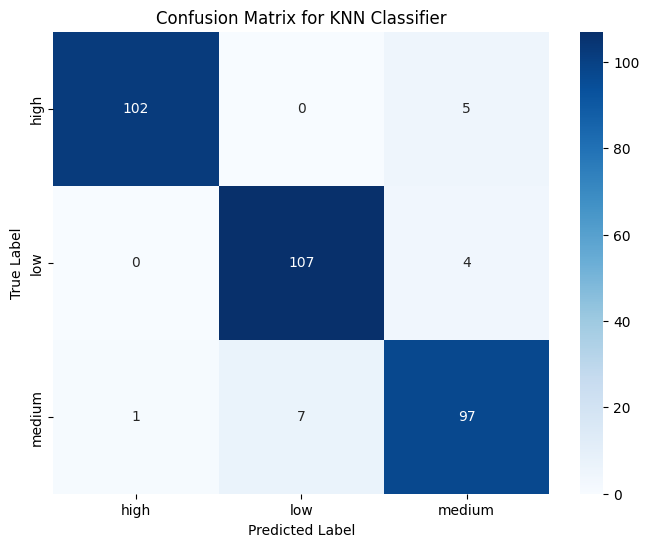

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

knn_classifier = KNeighborsClassifier()

param_grid = {
    'n_neighbors': list(range(1, 16)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}


grid_search_classifier = GridSearchCV(knn_classifier, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search_classifier.fit(X_train_class, y_train_class)


print("Best parameters for KNN Classifier:", grid_search_classifier.best_params_)
print("Best cross-validation accuracy:", grid_search_classifier.best_score_)


y_pred_class = grid_search_classifier.best_estimator_.predict(X_test_class)


print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class))

cm = confusion_matrix(y_test_class, y_pred_class)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=grid_search_classifier.best_estimator_.classes_,
            yticklabels=grid_search_classifier.best_estimator_.classes_)
plt.title('Confusion Matrix for KNN Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
columns_to_exclude = ['wine', 'beer', 'vodka', 'champagne', 'brandy']
X = X.drop(columns=columns_to_exclude)
X.head()

,year,region_Altai Krai,region_Altai Republic,region_Amur Oblast,region_Arkhangelsk Oblast,region_Astrakhan Oblast,region_Belgorod Oblast,region_Bryansk Oblast,region_Chechen Republic,region_Chelyabinsk Oblast,...,region_Tyumen Oblast,region_Udmurt Republic,region_Ulyanovsk Oblast,region_Vladimir Oblast,region_Volgograd Oblast,region_Vologda Oblast,region_Voronezh Oblast,region_Yamalo-Nenets Autonomous Okrug,region_Yaroslavl Oblast,region_Zabaykalsky Krai
0,1998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1998,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1998,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1998,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1998,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
y_reg = df['total_alcohol_consumption']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

print("Data split for  regression successfully.")
print(f"X_train_reg shape: {X_train_reg.shape}")
print(f"X_test_reg shape: {X_test_reg.shape}")
print(f"y_train_reg shape: {y_train_reg.shape}")
print(f"y_test_reg shape: {y_test_reg.shape}")

Data split for  regression successfully.
X_train_reg shape: (1292, 86)
X_test_reg shape: (323, 86)
y_train_reg shape: (1292,)
y_test_reg shape: (323,)


In [ ]:
knn_regressor = KNeighborsRegressor()

param_grid_reg = {
    'n_neighbors': list(range(1, 16)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_reg = GridSearchCV(knn_regressor, param_grid_reg, cv=5, scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error'}, refit='r2', n_jobs=-1)

grid_search_reg.fit(X_train_reg, y_train_reg)

print("Best parameters for KNN Regressor:", grid_search_reg.best_params_)
print("Best cross-validation R-squared :", grid_search_reg.best_score_)

y_pred_reg = grid_search_reg.best_estimator_.predict(X_test_reg)

r2 = r2_score(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)

print(f"R-squared on test set: {r2:.4f}")
print(f"Mean Absolute Error on test set: {mae:.4f}")

Best parameters for KNN Regressor: {'metric': 'manhattan', 'n_neighbors': 2, 'weights': 'distance'}
Best cross-validation R-squared : 0.7270106743675931
R-squared on test set: 0.7761
Mean Absolute Error on test set: 8.4407


In [ ]:
plot_df = pd.DataFrame({
    'year': X_test_reg['year'].reset_index(drop=True),
    'Actual': y_test_reg.reset_index(drop=True),
    'Predicted': pd.Series(y_pred_reg)
})
plot_df.head()

,year,Actual,Predicted
0,1999,36.00000,42.233333
1,2013,57.30000,58.500000
2,2011,97.78000,95.850000
3,2009,70.54716,87.098107
4,2007,91.40000,86.650000


In [ ]:
plot_df_grouped = plot_df.groupby('year')[['Actual', 'Predicted']].mean().reset_index()
plot_df_grouped.head()

,year,Actual,Predicted
0,1998,39.691956,41.720076
1,1999,43.270000,45.723095
2,2000,45.038889,45.310185
3,2001,64.237358,59.241572
4,2002,66.011235,57.773399


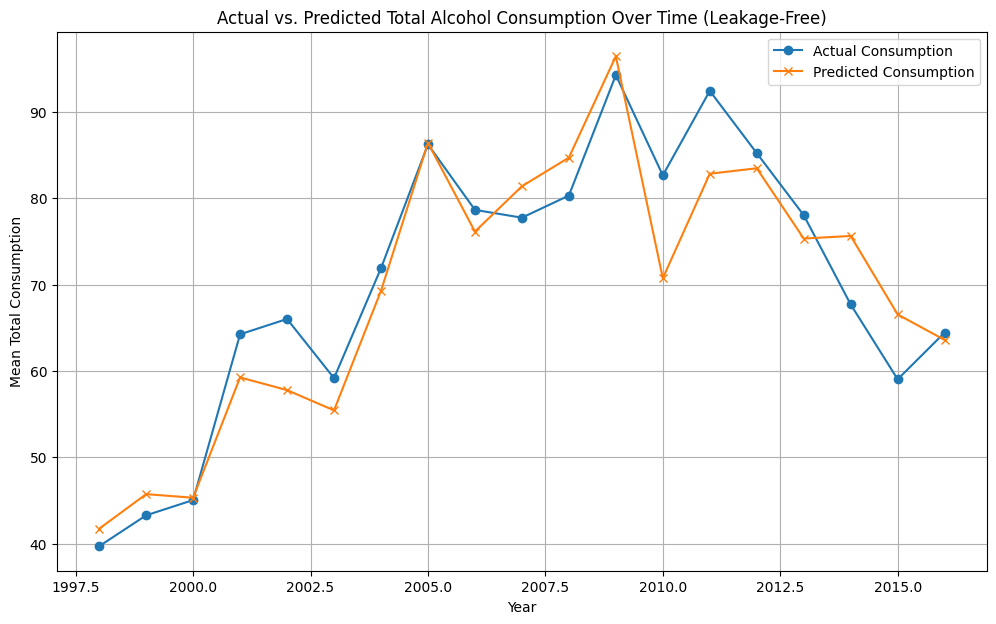

In [ ]:
plt.figure(figsize=(12, 7))
plt.plot(plot_df_grouped['year'], plot_df_grouped['Actual'], label='Actual Consumption', marker='o')
plt.plot(plot_df_grouped['year'], plot_df_grouped['Predicted'], label='Predicted Consumption', marker='x')

plt.title('Actual vs. Predicted Total Alcohol Consumption Over Time (Leakage-Free)')
plt.xlabel('Year')
plt.ylabel('Mean Total Consumption')
plt.legend()
plt.grid(True)
plt.show()